# Data Explorations

Notebook to explore some of the ERA5 data, and get a feel for what's going on.

In [1]:
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [8]:
temp_dat_winter

<xarray.Dataset>
Dimensions:    (longitude: 5, latitude: 5, time: 105408)
Coordinates:
  * longitude  (longitude) float32 123.0 123.2 123.5 123.8 124.0
  * latitude   (latitude) float32 -75.0 -75.25 -75.5 -75.75 -76.0
  * time       (time) datetime64[ns] 2000-04-01 ... 2023-09-30T23:00:00
Data variables:
    t2m        (time, latitude, longitude) float32 220.6 220.6 ... 214.2 214.2
Attributes:
    Conventions:  CF-1.6
    history:      2024-02-08 09:41:38 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

### Baby Pre-Processing

Done to get the daily maxima of temperatures and water vapor flux (notice, not necessarily concurrent within the hours of the day)! Need only run once to make the csv's.

In [2]:
temp_dat_winter = xr.load_dataset('~/extreme_antarctic_ARs/data/concordia_2m_temp_winter.nc')
ewvf_dat_winter = xr.load_dataset('~/extreme_antarctic_ARs/data/concordia_e_wvf_winter.nc')
nwvf_dat_winter = xr.load_dataset('~/extreme_antarctic_ARs/data/concordia_n_wvf_winter.nc')

temp_dat_summer = xr.load_dataset('~/extreme_antarctic_ARs/data/concordia_2m_temp_summer.nc')
ewvf_dat_summer = xr.load_dataset('~/extreme_antarctic_ARs/data/concordia_e_wvf_summer.nc')
nwvf_dat_summer = xr.load_dataset('~/extreme_antarctic_ARs/data/concordia_n_wvf_summer.nc')

tot_dat_winter = xr.merge([temp_dat_winter, ewvf_dat_winter, nwvf_dat_winter])
tot_dat_winter = tot_dat_winter.rename_vars({'t2m':'temp2m', 'p71.162':'ewvf', 'p72.162':'nwvf'})
tot_dat_winter['temp2m'] = tot_dat_winter['temp2m'] - 273.15
tot_dat_winter['nwvf'] = tot_dat_winter['nwvf']*(-1)
tot_dat_winter = tot_dat_winter.rename_vars({'nwvf':'swvf'})

tot_dat_summer = xr.merge([temp_dat_summer, ewvf_dat_summer, nwvf_dat_summer])
tot_dat_summer = tot_dat_summer.rename_vars({'t2m':'temp2m', 'p71.162':'ewvf', 'p72.162':'nwvf'})
tot_dat_summer['temp2m'] = tot_dat_summer['temp2m'] - 273.15
tot_dat_summer['nwvf'] = tot_dat_summer['nwvf']*(-1)
tot_dat_summer = tot_dat_summer.rename_vars({'nwvf':'swvf'})

In [3]:
one_cell_winter = tot_dat_winter.sel(longitude=123.0, latitude=-75.0)
one_cell_summer = tot_dat_summer.sel(longitude=123.0, latitude=-75.0)
daily_maxima_winter = one_cell_winter.groupby('time.date').max()
daily_maxima_summer = one_cell_summer.groupby('time.date').max()
daily_maxima_winter['date'] = pd.DatetimeIndex(daily_maxima_winter.date)
daily_maxima_summer['date'] = pd.DatetimeIndex(daily_maxima_summer.date)

In [4]:
daily_max_df_winter = daily_maxima_winter.to_dataframe()
daily_max_df_summer = daily_maxima_summer.to_dataframe()
daily_max_df_winter.to_csv('daily_max_df_winter.csv', sep='\t')
daily_max_df_summer.to_csv('daily_max_df_summer.csv', sep='\t')

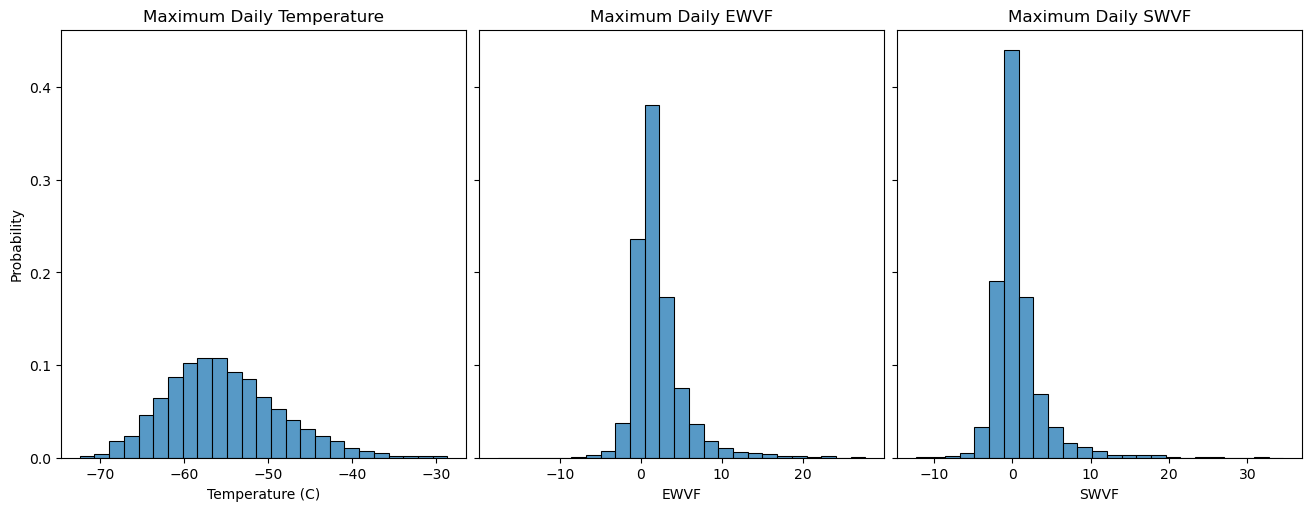

In [5]:
fig, axs = plt.subplots(nrows=1, ncols=3, layout='constrained', figsize=(13,5), sharey=True)
sns.histplot(data=daily_max_df_winter.temp2m, bins = 25, ax=axs[0], stat='probability')
axs[0].set_title('Maximum Daily Temperature')
axs[0].set_xlabel('Temperature (C)')
sns.histplot(data=daily_max_df_winter.ewvf, bins = 25, ax=axs[1], stat='probability')
axs[1].set_title('Maximum Daily EWVF')
axs[1].set_xlabel('EWVF')
sns.histplot(data=daily_max_df_winter.swvf, bins = 25, ax=axs[2], stat='probability')
axs[2].set_title('Maximum Daily SWVF')
axs[2].set_xlabel('SWVF');

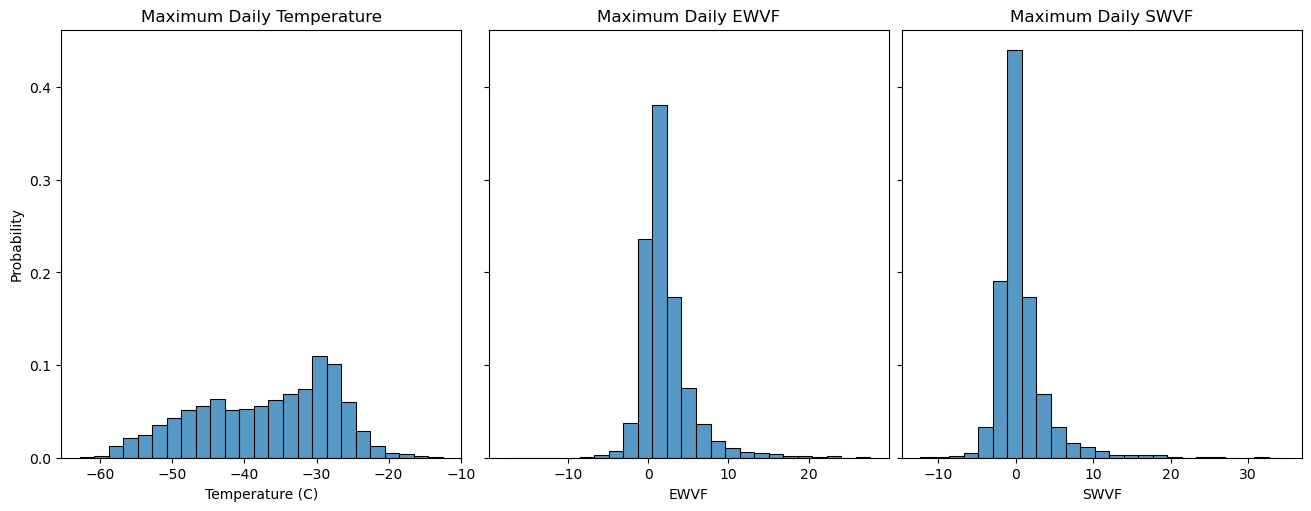

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=3, layout='constrained', figsize=(13,5), sharey=True)
sns.histplot(data=daily_max_df_summer.temp2m, bins = 25, ax=axs[0], stat='probability')
axs[0].set_title('Maximum Daily Temperature')
axs[0].set_xlabel('Temperature (C)')
sns.histplot(data=daily_max_df_summer.ewvf, bins = 25, ax=axs[1], stat='probability')
axs[1].set_title('Maximum Daily EWVF')
axs[1].set_xlabel('EWVF')
sns.histplot(data=daily_max_df_summer.swvf, bins = 25, ax=axs[2], stat='probability')
axs[2].set_title('Maximum Daily SWVF')
axs[2].set_xlabel('SWVF');

In [11]:
ewvf_dat_summer.time.groupby('time.year')

DataArrayGroupBy, grouped over 'year'
24 groups with labels 2000, 2001, 2002, ..., 2022, 2023.

In [85]:
temp_dat_summer

<xarray.Dataset>
Dimensions:    (longitude: 5, latitude: 5, expver: 2, time: 104976)
Coordinates:
  * longitude  (longitude) float32 123.0 123.2 123.5 123.8 124.0
  * latitude   (latitude) float32 -75.0 -75.25 -75.5 -75.75 -76.0
  * expver     (expver) int32 1 5
  * time       (time) datetime64[ns] 2000-01-01 ... 2023-12-31T23:00:00
Data variables:
    t2m        (time, expver, latitude, longitude) float32 240.1 240.1 ... 242.4
Attributes:
    Conventions:  CF-1.6
    history:      2024-02-15 09:13:23 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [38]:
daily_max_df_winter.swvf

date
2000-04-01   -0.840342
2000-04-02   -1.148730
2000-04-03   -1.169409
2000-04-04   -2.777884
2000-04-05   -0.748635
                ...   
2023-09-26   -2.065804
2023-09-27   -0.741442
2023-09-28   -0.743240
2023-09-29    0.434570
2023-09-30    0.137870
Name: swvf, Length: 4392, dtype: float32

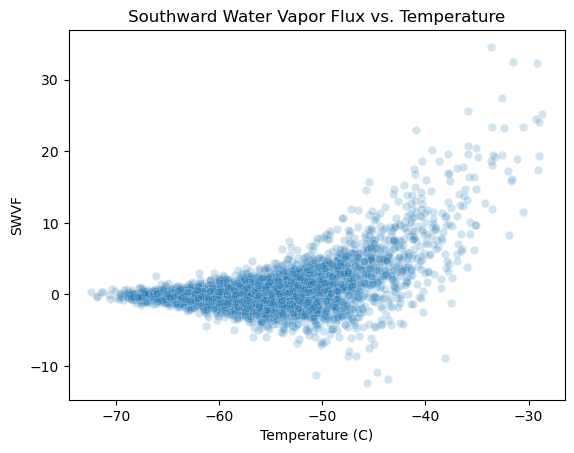

In [8]:
sns.scatterplot(data=daily_maxima, x='temp2m', y='swvf', alpha=0.2)
plt.title('Southward Water Vapor Flux vs. Temperature')
plt.ylabel('SWVF')
plt.xlabel('Temperature (C)');

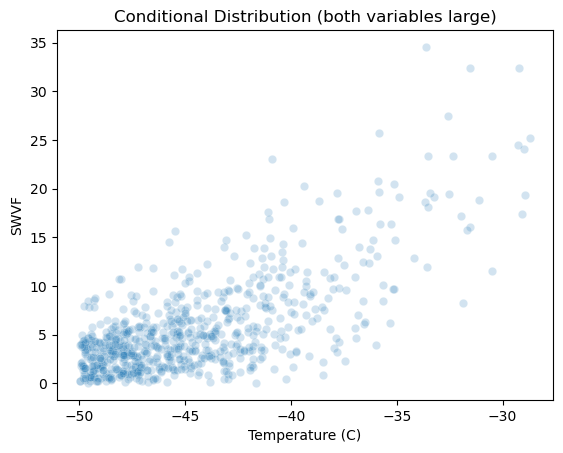

In [9]:
upper_right = daily_maxima.where((daily_maxima['temp2m'] >= -50) & (daily_maxima['swvf'] >= 0), drop=True)
sns.scatterplot(data=upper_right, x='temp2m', y='swvf', alpha=0.2)
plt.title('Conditional Distribution (both variables large)')
plt.ylabel('SWVF')
plt.xlabel('Temperature (C)');